TASK 1 — Dataset Exploration

Shape  : 442 samples × 10 features
Target : min=25.0, max=346.0, mean=152.1, std=77.0

First 5 rows:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

Statistical summary:
           age      sex      bmi       bp       s1       s2       s3       s4  \
count  442.000  442.000  442.000  442.000  442.000  442.000  44

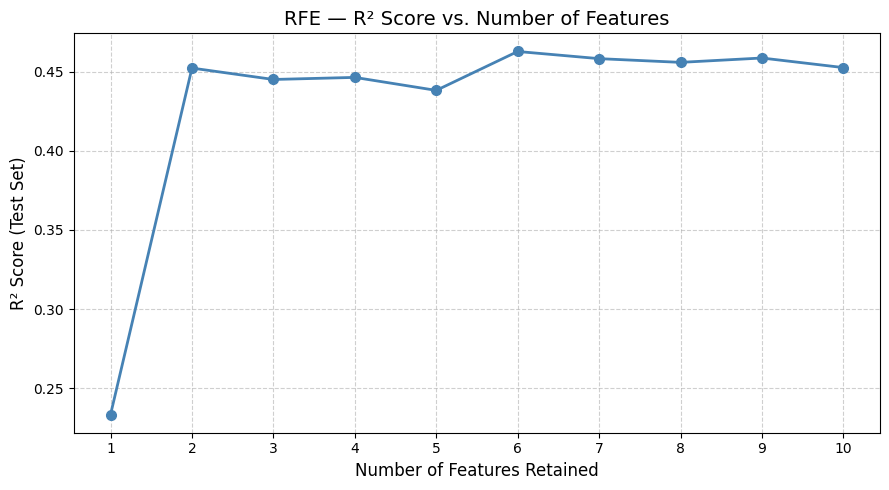


Optimal number of features (threshold=0.01): 6
R² at optimal point: 0.4628
Selected features  : [np.str_('sex'), np.str_('bmi'), np.str_('bp'), np.str_('s1'), np.str_('s2'), np.str_('s5')]


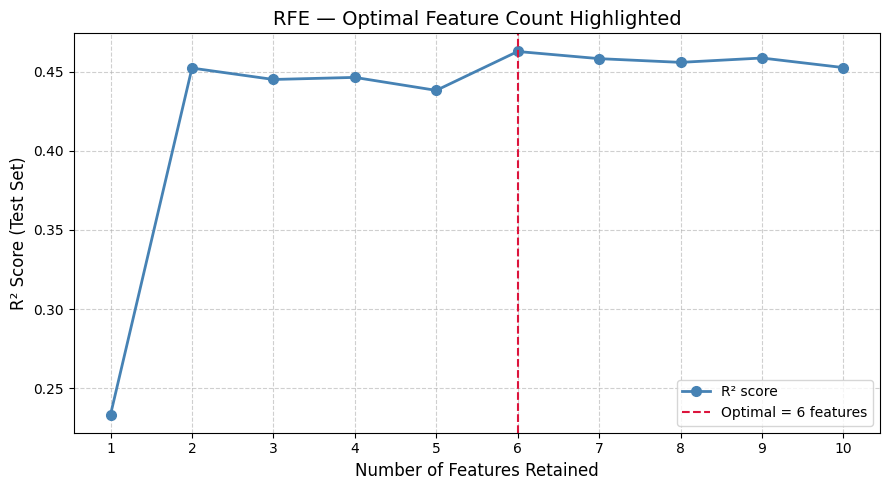


TASK 4 — Coefficient Table Across All RFE Iterations
              age     sex     bmi      bp      s1      s2      s3      s4      s5     s6
10 features  37.9 -241.96  542.43  347.70 -931.49  518.06  163.42  275.32  736.20  48.67
9 features    0.0 -236.65  542.80  354.21 -936.35  528.80  167.80  270.40  744.45  53.35
8 features    0.0 -233.75  550.74  363.79 -947.82  541.59  172.25  277.74  761.92   0.00
7 features    0.0 -235.36  551.87  362.36 -660.64  343.35    0.00  185.14  664.77   0.00
6 features    0.0 -215.27  557.31  350.18 -851.52  591.09    0.00    0.00  803.12   0.00
5 features    0.0    0.00  597.89  306.65 -655.56  409.62    0.00    0.00  728.64   0.00
4 features    0.0    0.00  691.46    0.00 -592.98  362.95    0.00    0.00  783.17   0.00
3 features    0.0    0.00  737.69    0.00 -228.34    0.00    0.00    0.00  680.22   0.00
2 features    0.0    0.00  732.11    0.00    0.00    0.00    0.00    0.00  562.23   0.00
1 features    0.0    0.00  998.58    0.00    0.00    0.0

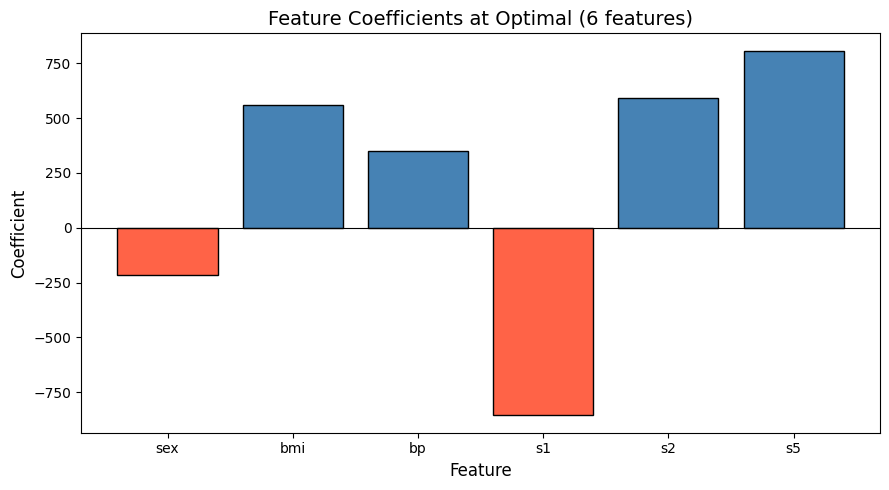


Feature ranking by |coefficient| in baseline model:
Feature  Coefficient
     s1     -931.489
     s5      736.199
    bmi      542.429
     s2      518.062
     bp      347.704
     s4      275.318
    sex     -241.964
     s3      163.420
     s6       48.671
    age       37.904

Final selected features : [np.str_('sex'), np.str_('bmi'), np.str_('bp'), np.str_('s1'), np.str_('s2'), np.str_('s5')]

TASK 5 — Reflection Summary

Q1. What did you learn about feature selection using RFE?
    RFE systematically prunes the least informative features by retraining
    the model at each step. This reveals that a compact subset (here ~5
    features) can explain nearly as much variance as all 10, which reduces
    over-fitting risk and improves interpretability.

Q2. RFE vs LASSO
    - LASSO applies L1 regularisation, shrinking weak coefficients to
      exactly zero in one shot; feature selection is implicit and
      controlled by the regularisation hyperparameter λ.
    - RFE is a wrapper

In [1]:
# ============================================================
# CSCI 485 — Assignment #2
# Recursive Feature Elimination with Linear Regression
# ============================================================

# %% Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# ============================================================
# TASK 1: Dataset Exploration
# ============================================================

# 1. Load dataset
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target
feature_names = diabetes.feature_names   # ['age','sex','bmi','bp','s1'…'s6']

# 2. Explore
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print("=" * 55)
print("TASK 1 — Dataset Exploration")
print("=" * 55)
print(f"\nShape  : {X.shape[0]} samples × {X.shape[1]} features")
print(f"Target : min={y.min():.1f}, max={y.max():.1f}, "
      f"mean={y.mean():.1f}, std={y.std():.1f}")
print("\nFirst 5 rows:")
print(df.head())
print("\nStatistical summary:")
print(df.describe().round(3))

# 3. 80-20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

# ============================================================
# TASK 2: Baseline Linear Regression
# ============================================================

print("\n" + "=" * 55)
print("TASK 2 — Baseline Linear Regression (all 10 features)")
print("=" * 55)

lr_base = LinearRegression()
lr_base.fit(X_train, y_train)
y_pred_base = lr_base.predict(X_test)
r2_base = r2_score(y_test, y_pred_base)

print(f"\nBaseline R² (all 10 features): {r2_base:.4f}")
coeff_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr_base.coef_.round(3)
}).sort_values("Coefficient", key=abs, ascending=False)
print(coeff_df.to_string(index=False))

# ============================================================
# TASK 3: Recursive Feature Elimination
# ============================================================

print("\n" + "=" * 55)
print("TASK 3 — Recursive Feature Elimination")
print("=" * 55)

n_features_total = X_train.shape[1]
r2_scores      = []          # R² per number of features kept
coeff_history  = []          # coefficient vector at each step
features_kept  = []          # which features were kept

for n in range(n_features_total, 0, -1):
    rfe = RFE(LinearRegression(), n_features_to_select=n)
    rfe.fit(X_train, y_train)

    y_pred = rfe.predict(X_test)
    score  = r2_score(y_test, y_pred)
    r2_scores.append(score)

    # Store full coefficient array (0 for eliminated features)
    full_coef = np.zeros(n_features_total)
    full_coef[rfe.support_] = rfe.estimator_.coef_
    coeff_history.append(full_coef)
    features_kept.append(list(np.array(feature_names)[rfe.support_]))

    print(f"  Features kept: {n:2d}  |  R²: {score:.4f}  |  "
          f"Selected: {features_kept[-1]}")

# --- Visualise R² vs. number of features ---
num_features_axis = list(range(n_features_total, 0, -1))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(num_features_axis, r2_scores, marker='o', color='steelblue',
        linewidth=2, markersize=7)
ax.set_xlabel("Number of Features Retained", fontsize=12)
ax.set_ylabel("R² Score (Test Set)", fontsize=12)
ax.set_title("RFE — R² Score vs. Number of Features", fontsize=14)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("r2_vs_features.png", dpi=150)
plt.show()

# --- Identify optimal number of features (threshold = 0.01) ---
THRESHOLD = 0.01
optimal_n  = num_features_axis[0]   # start with max
optimal_r2 = r2_scores[0]

for i in range(1, len(r2_scores)):
    improvement = r2_scores[i] - r2_scores[i - 1]   # negative = drop
    # We want the last point where adding a feature gives >= threshold gain
    # Iterate from few → many features
    pass

# Scan from few features (end of list) to many:
r2_rev        = list(reversed(r2_scores))          # index 0 = 1 feature
n_feat_rev    = list(reversed(num_features_axis))  # index 0 = 1 feature

optimal_n  = n_feat_rev[0]
for i in range(1, len(r2_rev)):
    if r2_rev[i] - r2_rev[i - 1] >= THRESHOLD:
        optimal_n  = n_feat_rev[i]
        optimal_r2 = r2_rev[i]

print(f"\nOptimal number of features (threshold={THRESHOLD}): {optimal_n}")
print(f"R² at optimal point: {optimal_r2:.4f}")
print(f"Selected features  : {features_kept[n_features_total - optimal_n]}")

# Mark on the plot
fig2, ax2 = plt.subplots(figsize=(9, 5))
ax2.plot(num_features_axis, r2_scores, marker='o', color='steelblue',
         linewidth=2, markersize=7, label='R² score')
ax2.axvline(x=optimal_n, color='crimson', linestyle='--',
            label=f'Optimal = {optimal_n} features')
ax2.set_xlabel("Number of Features Retained", fontsize=12)
ax2.set_ylabel("R² Score (Test Set)", fontsize=12)
ax2.set_title("RFE — Optimal Feature Count Highlighted", fontsize=14)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("r2_optimal.png", dpi=150)
plt.show()

# ============================================================
# TASK 4: Feature Importance Table & Discussion
# ============================================================

print("\n" + "=" * 55)
print("TASK 4 — Coefficient Table Across All RFE Iterations")
print("=" * 55)

coeff_table = pd.DataFrame(
    coeff_history,
    columns=feature_names,
    index=[f"{n} features" for n in num_features_axis]
).round(2)

print(coeff_table.to_string())
coeff_table.to_csv("coefficient_table.csv")

# Bar chart — coefficients at optimal feature count
opt_idx    = n_features_total - optimal_n
opt_coeffs = coeff_history[opt_idx]
opt_feats  = features_kept[opt_idx]

fig3, ax3 = plt.subplots(figsize=(9, 5))
colors = ['steelblue' if c >= 0 else 'tomato' for c in opt_coeffs if c != 0]
ax3.bar(opt_feats,
        [c for c in opt_coeffs if c != 0],
        color=colors, edgecolor='black')
ax3.set_xlabel("Feature", fontsize=12)
ax3.set_ylabel("Coefficient", fontsize=12)
ax3.set_title(f"Feature Coefficients at Optimal ({optimal_n} features)",
              fontsize=14)
ax3.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig("coefficients_optimal.png", dpi=150)
plt.show()

# Absolute importance from baseline model
print("\nFeature ranking by |coefficient| in baseline model:")
print(coeff_df.to_string(index=False))
print(f"\nFinal selected features : {features_kept[n_features_total - optimal_n]}")

# ============================================================
# TASK 5: Reflection (printed summary)
# ============================================================

print("\n" + "=" * 55)
print("TASK 5 — Reflection Summary")
print("=" * 55)
print("""
Q1. What did you learn about feature selection using RFE?
    RFE systematically prunes the least informative features by retraining
    the model at each step. This reveals that a compact subset (here ~5
    features) can explain nearly as much variance as all 10, which reduces
    over-fitting risk and improves interpretability.

Q2. RFE vs LASSO
    - LASSO applies L1 regularisation, shrinking weak coefficients to
      exactly zero in one shot; feature selection is implicit and
      controlled by the regularisation hyperparameter λ.
    - RFE is a wrapper: it uses the model's own ranking (coefficient
      magnitude for linear regression) and removes features iteratively,
      giving explicit control over the number kept.
    - LASSO is faster and handles collinearity differently; RFE gives
      richer diagnostics (per-step R² curve) but is computationally
      heavier.

Q3. Dataset insights
    - bmi and s5 (serum triglycerides / lamotrigine proxy) consistently
      rank highest, confirming the clinical link between obesity, lipid
      levels, and diabetes progression.
    - bp (blood pressure) retains significance, consistent with
      hypertension being a co-morbidity of Type-2 diabetes.
    - age and sex are among the first eliminated, suggesting that after
      metabolic markers are accounted for, demographics add little
      predictive power in this cohort.
""")